In [1]:
import numpy as np
import time

import mujoco
import mujoco.viewer

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import pinocchio as pin
from pinocchio.robot_wrapper import RobotWrapper
from pinocchio import rpy

from scipy.interpolate import CubicSpline
import proxsuite
import osqp
import scipy.sparse as sp

In [2]:
MJCF_PATH = '/home/frlab/mj_opt/xmls/systems/universal_robots_ur5e/scene.xml'
URDF_PATH = '/home/frlab/mj_opt/xmls/robots/ur_description/urdf/ur5e.urdf'
PACKAGE_DIRS = '/home/frlab/mj_opt/xmls/robots'

Q_MIN  = np.array([-6.283, -6.283, -3.141, -6.283, -6.283, -6.283])
Q_MAX  = np.array([ 6.283,  6.283,  3.141,  6.283,  6.283,  6.283])
DQ_MAX = np.full(6, np.pi)   # 모든 관절 동일 (3.141 rad/s)

In [3]:
class ConfigurationState:

    def __init__(self):

        self.ur5e_qpos = np.array([-1.5708, -1.5708,  1.5708, -1.5708, -1.5708,  0.    ])
        self.ur5_qvel = np.array([0, 0, 0, 0, 0, 0])

    def get_fixed_base_qpos(self):
        # ur5e는 6x1
        qpos = np.concatenate([self.ur5e_qpos])

        return qpos

    def get_fixed_base_qvel(self):
        # ur5e는 6x1
        qvel = np.concatenate([self.ur5_qvel])

        return qvel
    
    def get_floating_base_qpos(self):
        pass

    def get_floating_base_qvel(self):
        pass

    def update_qpos(self, qpos):
        self.ur5e_qpos = qpos.copy()
    
    def update_qvel(self, qvel):
        self.ur5_qvel = qvel.copy()
    
    # 추후에 newton simulator는 qx qy qz qw임 
    def mjquat_2_rpy(self):
        # mujoco의 quat 순서
        qx, qy, qz, qw = self.base_quat
        # pinocchio의 quat 순서
        pin_quat = pin.Quaternion(qw, qx, qy, qz) 
        # 쿼터니언(4)을 회전행렬(9)로 
        R = pin_quat.toRotationMatrix()
        # 회전행렬을 다시 rpy로
        rpy = pin.rpy.matrixToRpy(R)
        roll, pitch, yaw_meas = np.array(rpy).reshape(3, )
        
        # 백플립 동작이 아닌 이상 yaw를 제외한 각이 180도를 초과하기는 어려움
        # 따라서 제자리 회전이 가능하도록 마치 모터의 싱글턴, 멀티턴
        if not hasattr(self, "_yaw_unwrap_initialized"):
            self._yaw_unwrap_initialized = True
            self._yaw_prev_meas = yaw_meas
            self._yaw_cont = yaw_meas
        else:
            # 3) unwrap: keep smallest change between steps
            yaw_delta = (yaw_meas - self._yaw_prev_meas + np.pi) % (2 * np.pi) - np.pi
            self._yaw_cont += yaw_delta
            self._yaw_prev_meas = yaw_meas

        return np.array([roll, pitch, self._yaw_cont])
    
    def rpy_2_quat(self, roll, pitch, yaw):

        cr,sr = np.cos(roll/2), np.sin(roll/2)
        cp,sp = np.cos(pitch/2), np.sin(pitch/2)
        cy,sy = np.cos(yaw/2), np.sin(yaw/2)
        
        qx = sr*cp*cy - cr*sp*sy
        qy = cr*sp*cy + sr*cp*sy
        qz = cr*cp*sy - sr*sp*cy
        qw = cr*cp*cy + sr*sp*sy

        self.base_quat = np.array([qx, qy, qz, qw])

### fixed base 6DOF Manipulator 기준 Pin2Mj

In [4]:
class Pinocchio_2_Mujoco:

    def __init__(self):

        robot = RobotWrapper.BuildFromURDF(
            str(URDF_PATH),
            package_dirs = [str(PACKAGE_DIRS)],
            root_joint = None, # 만약 floating base라면 JointModelFreeFlyer()
        )
      
        self.model = robot.model
        self.vmodel = robot.visual_model
        self.cmodel = robot.collision_model
        self.data = self.model.createData()

        #
        self.current_config = ConfigurationState()
        self.qpos_init = self.current_config.get_fixed_base_qpos()
        self.qvel_init = self.current_config.get_fixed_base_qvel()

        # FK
        pin.forwardKinematics(self.model, self.data, self.qpos_init)
        pin.updateFramePlacements(self.model, self.data)
        
        # 조작하길 원하는 id
        self.base_id = self.model.getFrameId("base")
        self.ee_id = self.model.getFrameId("tool0")
        self.oMf = self.data.oMf[self.ee_id]

    def get_ee_state_in_world(self):
        ee_pos_world = self.oMf.translation.copy() # 3x1
        quat_pin = pin.Quaternion(self.oMf.rotation)
        ee_quat_world = np.array([quat_pin.w, quat_pin.x, quat_pin.y, quat_pin.z])
        R = quat_pin.toRotationMatrix()
        ee_rot_world = pin.rpy.matrixToRpy(R).flatten() # 3x1
        v6 = pin.getFrameVelocity(self.model, self.data, self.ee_id, pin.ReferenceFrame.LOCAL_WORLD_ALIGNED)
        ee_lin_world = np.array(v6.linear).copy()  # 3x1
        ee_ang_world = np.array(v6.angular).copy() # 3x1
        return ee_pos_world, ee_rot_world, ee_lin_world, ee_ang_world

    # 월드 좌표계 기준 자코비안
    def compute_6x6_ee_Jacobian_world(self):
        J_world = pin.getFrameJacobian(self.model, self.data, self.ee_id, pin.ReferenceFrame.LOCAL_WORLD_ALIGNED)
        J_pos_world = J_world[:3, :] # 3x6 linear velocity 행렬
        J_rot_world = J_world[3:, :] # 3x6 angluar velocity 행렬

        return J_pos_world, J_rot_world

    # 바디 좌표계 기준 자코비안
    def compute_6x6_ee_Jacobian_body(self):
        J_body = pin.getFrameJacobian(self.model, self.data, self.ee_id, pin.ReferenceFrame.LOCAL)
        J_pos_body = J_body[:3, :] # 3x6 linear velocity 행렬
        J_rot_body = J_body[3:, :] # 3x6 angluar velocity 행렬
        return J_pos_body, J_rot_body

    # 
    def compute_Jdot_dq_world(self):
        Jdot = pin.getFrameJacobianTimeVariation(self.model, self.data, self.ee_id, pin.ReferenceFrame.LOCAL_WORLD_ALIGNED)
        Jdot_dq = Jdot @ self.current_config.get_fixed_base_qvel() # 6x6
        return np.asarray(Jdot_dq).reshape(6,) 
    
    #
    def compute_Jdot_dq_body(self):
        Jdot = pin.getFrameJacobianTimeVariation(self.model, self.data, self.ee_id, pin.ReferenceFrame.LOCAL)
        Jdot_dq = Jdot @ self.current_config.get_fixed_base_qvel() # 6x6
        return np.asarray(Jdot_dq).reshape(6,)
    
    # 부유 모델일 경우 추가 필요

    def compute_dynamics_term(self):
        g = self.data.g # 6x1 중력
        C = self.data.C # 6x6 코리올리
        M = self.data.M # 6x6 joint space 관성

        return M, C, g
    
    def update_model(self, q, dq):
        self.current_config.update_qpos(q)
        self.current_config.update_qvel(dq)
        pin.computeAllTerms(self.model, self.data, q, dq)
        pin.updateFramePlacements(self.model, self.data) 
        pin.computeJointJacobiansTimeVariation(self.model, self.data, q, dq)
        self.oMf = self.data.oMf[self.ee_id]

### pinocchio lib 네이밍 컨벤션

oMf: Origin Matrix Frame -> 월드에서 바라본 특정 프레임의 Pose (4x4)
oMb: Origin Matrix Body  -> 월드에서 바라본 바디 Pose  (4x4)

### 피노키오의 레퍼런스 프레임 종류

1. pin.ReferenceFrame.WORLD
Modern Robotics의 Space Jacobian과 동일

2. pin.ReferenceFrame.LOCAL
Modern Robotics의 Body Jacobian과 동일

3. pin.ReferenceFrame.LOCAL_WORLD_ALIGNED
원점은 EE 그러나 X, Y, Z 축의 방향은 World 좌표계와 평행

In [5]:
class Mujoco_6_DOF_Manipulator:
    def __init__(self):

        self.model = mujoco.MjModel.from_xml_path(MJCF_PATH)
        self.data = mujoco.MjData(self.model)
        self.ee_name = "attachment_site"  
        self.ee_id = self.data.site(self.ee_name).id


    def update_pin_with_mujoco(self, manipulator):

        mujoco_q = np.asarray(self.data.qpos)  # 6x1
        mujoco_dq = np.asarray(self.data.qvel) # 6x1
        current_pos = pin_model.oMf.translation
        current_R = pin_model.oMf.rotation
        current_ori = pin_model.ee_rot_world

        pin_q = mujoco_q
        pin_dq = mujoco_dq

        manipulator.update_model(mujoco_q, mujoco_dq)
        

    def position_command(self, desired_postion):

        self.data.ctrl[:6] = desired_postion

#### 시뮬레이션 함수에서 보간하는 함수명만 바꾸고 최종적으로 vel plot을 보면 smooth 차이 확인 가능
quintic는 5차이므로 a가 부드럽다 따라서 v가 부드러움 그러나 cubic은 3차이므로 v가 불연속임

In [6]:
def generate_se3_spline_trajectory(wp_pos, wp_rot, seg_duration, dt):
    T_wp = [pin.SE3(R, p) for R, p in zip(wp_rot, wp_pos)]
    T_ref = T_wp[0]
    xi_wp = np.array([pin.log6(T_ref.inverse() * Ti).vector for Ti in T_wp])

    t_wp = np.arange(len(T_wp)) * seg_duration
    cs = CubicSpline(t_wp, xi_wp, bc_type='clamped')
    t_s = np.arange(0, t_wp[-1], dt)
    xi = cs(t_s)      # (N, 6)
    xi_d = cs(t_s, 1) # (N, 6) ← traj_twist

    pos = np.zeros((len(t_s), 3))
    rot = np.zeros((len(t_s), 3, 3))
    for i, v in enumerate(xi):
        T_t = T_ref * pin.exp6(pin.Motion(v))
        pos[i] = T_t.translation
        rot[i] = T_t.rotation

    return t_s, pos, rot, xi_d

In [7]:
'''
class TaskSpaceController:
    def __init__(self):
        self.I = np.eye(6)
        self.Kp_pos = 25 * np.eye(3)
        self.Kp_ori = 25 * np.eye(3)  
        self.damping = 1e-3              
        self._qp = proxsuite.proxqp.dense.QP(6, 0, 0, box_constraints=True)
        self._qp.settings.max_iter = 5000
        self._qp.settings.eps_abs  = 1e-2
        self._qp.settings.eps_rel  = 1e-2
        self._qp_initalized = False


    def compute_IK_QP(self, target_twist, twist_error, J, q_current, q_min, q_max, dq_max, ctrl_dt):
        # 계산
        V_pos_desired = target_twist[:3] + self.Kp_pos @ twist_error[:3] # 3x1
        V_ori_desired = target_twist[3:] + self.Kp_ori @ twist_error[3:] # 3x1
        V_desired = np.concatenate([V_pos_desired, V_ori_desired])
        
        # 행렬 구성
        H = J.T @ J + self.damping * self.I # 6x6 Hessian
        g = -J.T @ V_desired                # 6,  Linear

        # 제약조건
        lb = -dq_max
        ub = dq_max

        lb = np.maximum(lb, (q_min - q_current) / ctrl_dt)
        ub = np.minimum(ub, (q_max - q_current) / ctrl_dt)
        lb = np.minimum(lb, ub)

        if not self._qp_initalized:
            self._qp.init(H, g, None, None, None, None, None, lb, ub)
            self._qp_initalized = True
        else:
            self._qp.update(H=H, g=g, l_box=lb, u_box=ub)
        
        self._qp.solve()

        if self._qp.results.info.status == proxsuite.proxqp.QPSolverOutput.PROXQP_SOLVED:
            return self._qp.results.x
        else:
            print("QP 수렴 실패:", self._qp.results.info.status)
            return np.zeros(6)


    def compute_DLS(self, target_twist, twist_error, J):
        V_pos_desired = target_twist[:3] + self.Kp_pos @ twist_error[:3] # 3x1
        V_ori_desired = target_twist[3:] + self.Kp_ori @ twist_error[3:] # 3x1
        V_desired = np.concatenate([V_pos_desired, V_ori_desired])
        JJt = J @ J.T + self.damping * self.I
        desired_dq = J.T @ np.linalg.solve(JJt, V_desired)  # 6x1

        return desired_dq

    def calc_twist_error(self, current_pos, current_ori, target_pos, target_ori):
        pos_err = target_pos - current_pos
        R_err = target_ori @ current_ori.T
        ori_err = pin.log3(R_err)
        return np.concatenate((pos_err, ori_err)) # 6x1
'''

'\nclass TaskSpaceController:\n    def __init__(self):\n        self.I = np.eye(6)\n        self.Kp_pos = 25 * np.eye(3)\n        self.Kp_ori = 25 * np.eye(3)  \n        self.damping = 1e-3              \n        self._qp = proxsuite.proxqp.dense.QP(6, 0, 0, box_constraints=True)\n        self._qp.settings.max_iter = 5000\n        self._qp.settings.eps_abs  = 1e-2\n        self._qp.settings.eps_rel  = 1e-2\n        self._qp_initalized = False\n\n\n    def compute_IK_QP(self, target_twist, twist_error, J, q_current, q_min, q_max, dq_max, ctrl_dt):\n        # 계산\n        V_pos_desired = target_twist[:3] + self.Kp_pos @ twist_error[:3] # 3x1\n        V_ori_desired = target_twist[3:] + self.Kp_ori @ twist_error[3:] # 3x1\n        V_desired = np.concatenate([V_pos_desired, V_ori_desired])\n\n        # 행렬 구성\n        H = J.T @ J + self.damping * self.I # 6x6 Hessian\n        g = -J.T @ V_desired                # 6,  Linear\n\n        # 제약조건\n        lb = -dq_max\n        ub = dq_max\n\n     

In [8]:
class TaskSpaceController:
    def __init__(self):
        self.I       = np.eye(6)
        self.Kp_pos  = 50 * np.eye(3)
        self.Kp_ori  = 50 * np.eye(3)
        self.damping = 1e-3
        self._prob   = osqp.OSQP()
        self._osqp_initialized = False

    def compute_IK_QP(self, target_twist, twist_error, J,
                      q_current, q_min, q_max,
                      dq_max=np.full(6, np.pi), ctrl_dt=0.01):

        V = np.concatenate([
            target_twist[:3] + self.Kp_pos @ twist_error[:3],
            target_twist[3:] + self.Kp_ori @ twist_error[3:],
        ])
        H = J.T @ J + self.damping * self.I
        g = -J.T @ V

        lb = np.maximum(-dq_max, (q_min - q_current) / ctrl_dt)
        ub = np.minimum( dq_max, (q_max - q_current) / ctrl_dt)
        lb = np.minimum(lb, ub)  # infeasible 방지

        # OSQP: min 0.5 x^T P x + q^T x  s.t.  l <= Ax <= u
        P_sp = sp.csc_matrix(0.5 * (H + H.T))
        A_sp = sp.eye(6, format='csc')  # box constraint → A = I

        if not self._osqp_initialized:
            self._prob.setup(P_sp, g, A_sp, lb, ub,
                             verbose=False,
                             warm_starting=True,
                             eps_abs=1e-4, eps_rel=1e-4,
                             max_iter=1000)
            self._osqp_initialized = True
        else:
            self._prob.update(q=g, l=lb, u=ub)

        res = self._prob.solve()

        if res.info.status in ('solved', 'solved_inaccurate'):
            return res.x
        else:
            print("QP 실패:", res.info.status)
            return np.zeros(6)
        
    def calc_twist_error(self, current_pos, current_ori, target_pos, target_ori):
        pos_err = target_pos - current_pos
        R_err = target_ori @ current_ori.T
        ori_err = pin.log3(R_err)
        return np.concatenate((pos_err, ori_err)) # 6x1

In [9]:
pin_model = Pinocchio_2_Mujoco()
env = Mujoco_6_DOF_Manipulator()

# 무조코 데이터로 피노키오 업데이트
pin_model.update_model(env.data.qpos, env.data.qvel)

mujoco.mj_forward(env.model, env.data)
mujoco.mj_step(env.model, env.data)

# 피노키오 월드 기준 정렬된 엔드이펙터 자코비안 (name = tool0)
J_pin_pos_w, J_pin_rot_w = pin_model.compute_6x6_ee_Jacobian_world()
J_pin_world = np.concatenate([J_pin_pos_w, J_pin_rot_w])

# 무조코 월드 기준 정렬된 엔드이펙터 자코비안 (name = attachment_site)
J_full = np.zeros((6, env.model.nv))
mujoco.mj_jacSite(env.model, env.data, J_full[:3], J_full[3:], env.ee_id)

#### 가끔씩 다르게 나오는 경우가 있는데 그건 mjcf에서 world 또는 ground와 회전해서 연결되어 있어서 그런거임
#### 아마 floating base 로봇들은 괜찮을거라고 봄


In [10]:
np.set_printoptions(precision=4, suppress=True)

print("피노키오, 무조코 월드 프레임 기준 엔드이펙터 자코비안 비교")
print("오차 Norm:", np.linalg.norm(J_pin_world - J_full))

print(J_pin_world)
print(J_full)

피노키오, 무조코 월드 프레임 기준 엔드이펙터 자코비안 비교
오차 Norm: 0.0013266499500528604
[[-0.2329 -0.0997 -0.0997 -0.0997  0.0996  0.    ]
 [ 0.8172 -0.     -0.      0.      0.      0.    ]
 [ 0.     -0.8172 -0.3922  0.      0.      0.    ]
 [ 0.      0.      0.      0.     -0.      0.    ]
 [ 0.      1.      1.      1.     -0.      1.    ]
 [ 1.     -0.     -0.     -0.     -1.     -0.    ]]
[[-0.234 -0.1   -0.1   -0.1    0.1    0.   ]
 [ 0.817  0.     0.     0.     0.     0.   ]
 [ 0.    -0.817 -0.392  0.     0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.   ]
 [ 0.     1.     1.     1.     0.     1.   ]
 [ 1.     0.     0.     0.    -1.     0.   ]]


In [11]:
controller = TaskSpaceController()

# Pinocchio 모델을 현재 MuJoCo 상태로 한번 업데이트
pin_model.update_model(env.data.qpos, env.data.qvel)

# Pinocchio에서 초기 EE 위치와 회전 행렬 획득
init_ee_pos = pin_model.oMf.translation.copy()
init_ee_R = pin_model.oMf.rotation.copy()

# 회전(Orientation)은 제자리 유지를 위해 초기 자세를 타겟으로 고정
target_R = init_ee_R.copy()

In [12]:
def draw_axes(user_scn, pos, rot_mat, size=0.1):
    R = rot_mat.reshape(3, 3)
    colors = [
        [1, 0, 0, 1],  # X - 빨강
        [0, 1, 0, 1],  # Y - 초록
        [0, 0, 1, 1],  # Z - 파랑
    ]
    for i in range(3):
        if user_scn.ngeom >= user_scn.maxgeom:
            break
        end = pos + R[:, i] * size
        mujoco.mjv_initGeom(
            user_scn.geoms[user_scn.ngeom],
            mujoco.mjtGeom.mjGEOM_ARROW,
            np.zeros(3), np.zeros(3), np.zeros(9),
            np.array(colors[i], dtype=np.float32)
        )
        mujoco.mjv_connector(
            user_scn.geoms[user_scn.ngeom],
            mujoco.mjtGeom.mjGEOM_ARROW, 0.005,
            pos, end
        )
        user_scn.ngeom += 1

#### 이제 quintic + DLS로 PTP

In [13]:
# plot 1. 궤적 비교 3D
ee_pos_log= []
waypoints = []
times = []

# plot 2. 
ee_desired_position = []
ee_actual_position = []

# plot 3. DLS 출력 기반과 실제 EE 속도 비교
ee_desired_velocity = []
ee_actual_velocity = []

# plot 2. EE의 위치오차 
ee_error_pos_x = []
ee_error_pos_y = []
ee_error_pos_z = []

# plot 4. 관절 속도 부드러운지
q_log = []
dq_log = []

In [14]:
q_home = np.array([-1.5708, -1.5708, 1.5708, -1.5708, -1.5708, 0.])
env.data.qpos[:6] = q_home
env.data.qvel[:6] = 0.0
env.data.ctrl[:6] = q_home
mujoco.mj_forward(env.model, env.data)
pin_model.update_model(env.data.qpos, env.data.qvel)

init_ee_pos = pin_model.oMf.translation.copy()
init_ee_R   = pin_model.oMf.rotation.copy()

In [15]:
with mujoco.viewer.launch_passive(env.model, env.data,
                                  show_left_ui=False, show_right_ui=False) as viewer:
    
    # 버퍼 초기화 (루프 재실행 시 중복 방지)
    ee_pos_log.clear(); times.clear()
    ee_desired_position.clear(); ee_actual_position.clear()
    ee_desired_velocity.clear(); ee_actual_velocity.clear()
    ee_error_pos_x.clear(); ee_error_pos_y.clear(); ee_error_pos_z.clear()
    q_log.clear(); dq_log.clear()
    waypoints = []

    sim_time = 0.0
    integration_dt = env.model.opt.timestep  # 물리 엔진 스텝 (보통 0.002초 = 500Hz)

    # --- [1. 제어(Control) 주기 설정: 100Hz] ---
    ctrl_fps = 100
    ctrl_dt = 1.0 / ctrl_fps      # 0.01초
    next_ctrl_time = sim_time     # 다음 제어 로직이 실행될 시간

    # --- [2. 렌더링(Rendering) 주기 설정: 60Hz] ---
    render_fps = 60
    render_dt = 1.0 / render_fps  # 약 0.01667초
    next_render_time = sim_time
    
    # 목표 위치 설정
    wp_pos = [init_ee_pos,
          init_ee_pos + np.array([-0.2, 0.2, -0.1]),
          init_ee_pos + np.array([0.1, 0.0, -0.25]),
          init_ee_pos + np.array([-0.0, 0.1, -0.3])]
    
    
    wp_rot = [
        init_ee_R,
        init_ee_R, #@ rpy.rpyToMatrix(0,       0,      np.pi/4),
        init_ee_R, #@ rpy.rpyToMatrix(0,  np.pi/6,          0),
        init_ee_R] #@ rpy.rpyToMatrix(0,       0,      np.pi/2),]

    traj_t, traj_pos, traj_rot, traj_twist = generate_se3_spline_trajectory(wp_pos, wp_rot, 10, ctrl_dt)
    traj_len = len(traj_t)
    waypoints = np.array(wp_pos)

    start_wall_time = time.perf_counter()
    current_pos = init_ee_pos.copy()
    current_R = init_ee_R.copy()
    target_pos = traj_pos[0]
    target_R   = traj_rot[0]

    while viewer.is_running():
        
        # 물리 엔진은 렌더링 주기가 올 때까지 계속 돕니다.
        while sim_time < next_render_time and viewer.is_running():
            
            if sim_time >= next_ctrl_time:
                '''
                0. 궤적 
                '''
                traj_idx = min(int(sim_time / ctrl_dt), traj_len -1)
                target_pos = traj_pos[traj_idx]
                target_R     = traj_rot[traj_idx]
                target_twist = traj_twist[traj_idx]  
                
                '''
                1. 상태 업데이트
                '''
                pin_model.update_model(env.data.qpos, env.data.qvel)
                current_pos = pin_model.oMf.translation.copy()
                current_R = pin_model.oMf.rotation.copy()
                
                '''
                2. 제어
                '''
                J_pos, J_rot = pin_model.compute_6x6_ee_Jacobian_world()
                J_world = np.concatenate([J_pos, J_rot])

                twist_error = controller.calc_twist_error(current_pos, current_R, target_pos, target_R)
                dq = controller.compute_IK_QP(target_twist, twist_error, J_world, 
                                              q_current=env.data.qpos[:6].copy(), q_min=Q_MIN, q_max=Q_MAX, dq_max=DQ_MAX, ctrl_dt=ctrl_dt)

                q_current = env.data.qpos.copy() 
                q_target = np.zeros_like(q_current)
                mujoco.mj_integratePos(env.model, q_current, dq, ctrl_dt)
                q_target = q_current 

                env.data.ctrl[:6] = q_target[:6] 
                _, _, g = pin_model.compute_dynamics_term()
                env.data.qfrc_applied[:6] = g[:6]

                '''
                3. log할 데이터 저장
                '''
                times.append(sim_time)

                ee_pos_log.append(current_pos.copy())
                ee_desired_position.append(target_pos.copy())
                ee_actual_position.append(current_pos.copy())

                ee_error_pos_x.append(twist_error[0]) 
                ee_error_pos_y.append(twist_error[1])
                ee_error_pos_z.append(twist_error[2])
                
                ee_desired_velocity.append(np.linalg.norm(target_twist[:3])) 
                _, _, ee_lin_world, _ = pin_model.get_ee_state_in_world()
                ee_actual_velocity.append(np.linalg.norm(ee_lin_world))

                q_log.append(env.data.qpos.copy())
                dq_log.append(dq.copy())

                
                next_ctrl_time += ctrl_dt

            mujoco.mj_step(env.model, env.data)
            
            sim_time += integration_dt

        if hasattr(viewer.user_scn, 'ngeom'):
            viewer.user_scn.ngeom = 0 
            
        draw_axes(viewer.user_scn, target_pos, target_R, size=0.2)
        draw_axes(viewer.user_scn, current_pos, current_R, size=0.2)
        for p, R in zip(wp_pos, wp_rot):
            draw_axes(viewer.user_scn, p, R, size=0.2)
        
        viewer.sync()
        next_render_time += render_dt

        # 실시간 동기화 (Real-time Pacing)
        time_until_next_frame = (start_wall_time + sim_time) - time.perf_counter()
        if time_until_next_frame > 0:
            time.sleep(time_until_next_frame)

#### 경로 plot

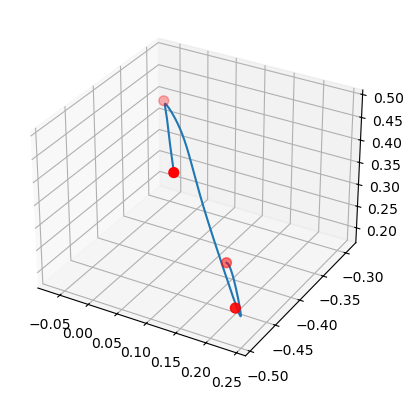

In [16]:
fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')
pos = np.array(ee_pos_log)
ax.plot(pos[:, 0], pos[:, 1], pos[:, 2])
ax.scatter(*waypoints.T, c='red', s=50)

#### EE 오차 norm plot

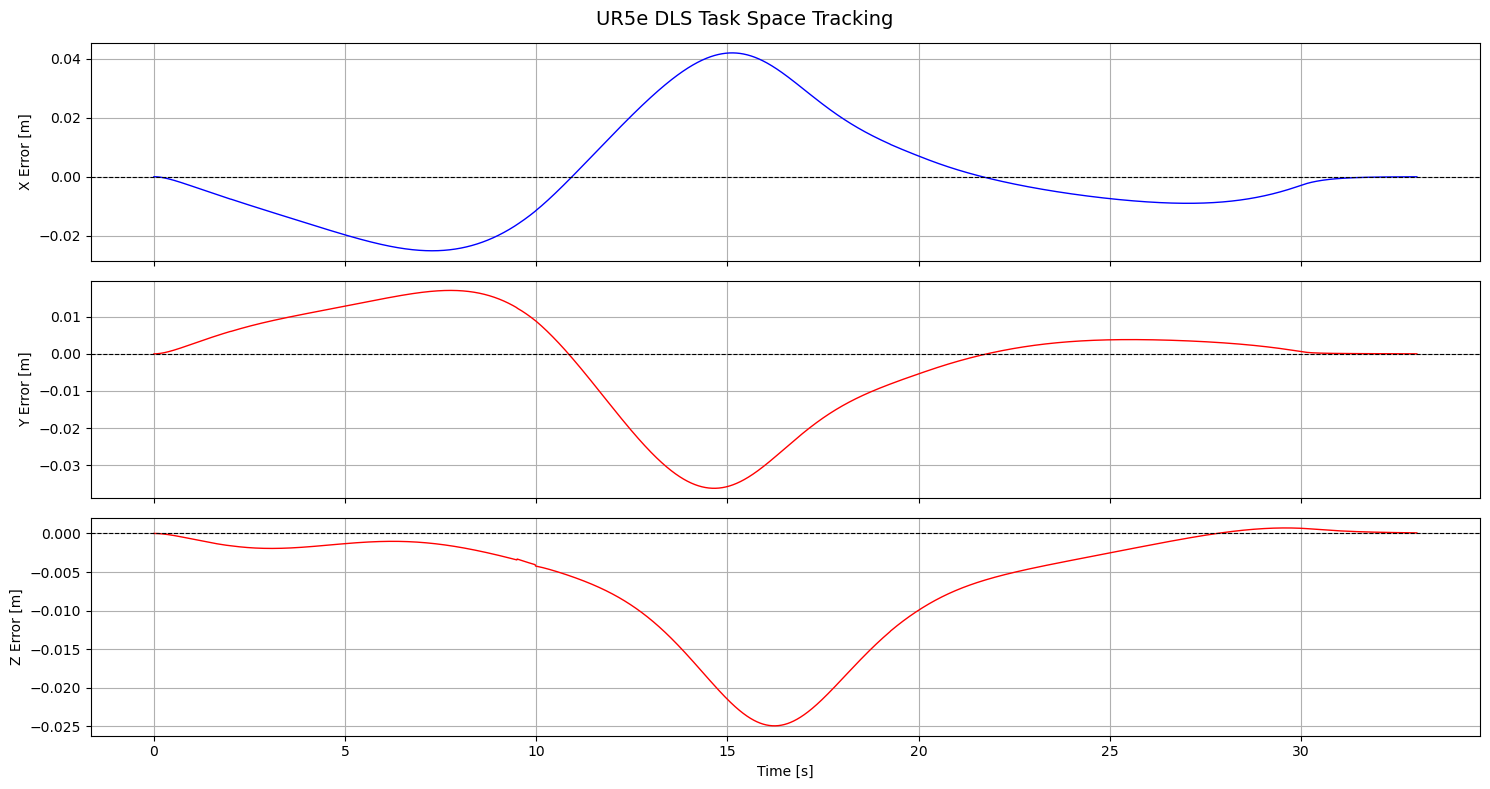

In [17]:
desired_position_arr = np.array(ee_desired_position)
actual_position_arr = np.array(ee_actual_position)
error_pos_x = np.array(ee_error_pos_x)
error_pos_y = np.array(ee_error_pos_y)
error_pos_z = np.array(ee_error_pos_z)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 8), sharex=True)
fig.suptitle('UR5e DLS Task Space Tracking', fontsize=14)

ax1.plot(times, error_pos_x, 'b-', linewidth=1)
ax1.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax1.set_ylabel('X Error [m]')
ax1.grid(True)

ax2.plot(times, error_pos_y, 'r-', linewidth=1)
ax2.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax2.set_ylabel('Y Error [m]')
ax2.grid(True)

ax3.plot(times, error_pos_z, 'r-', linewidth=1)
ax3.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax3.set_ylabel('Z Error [m]')
ax3.set_xlabel('Time [s]')
ax3.grid(True)

plt.tight_layout()
plt.show()

#### motion이 부드러운지 EE 선속도 크기

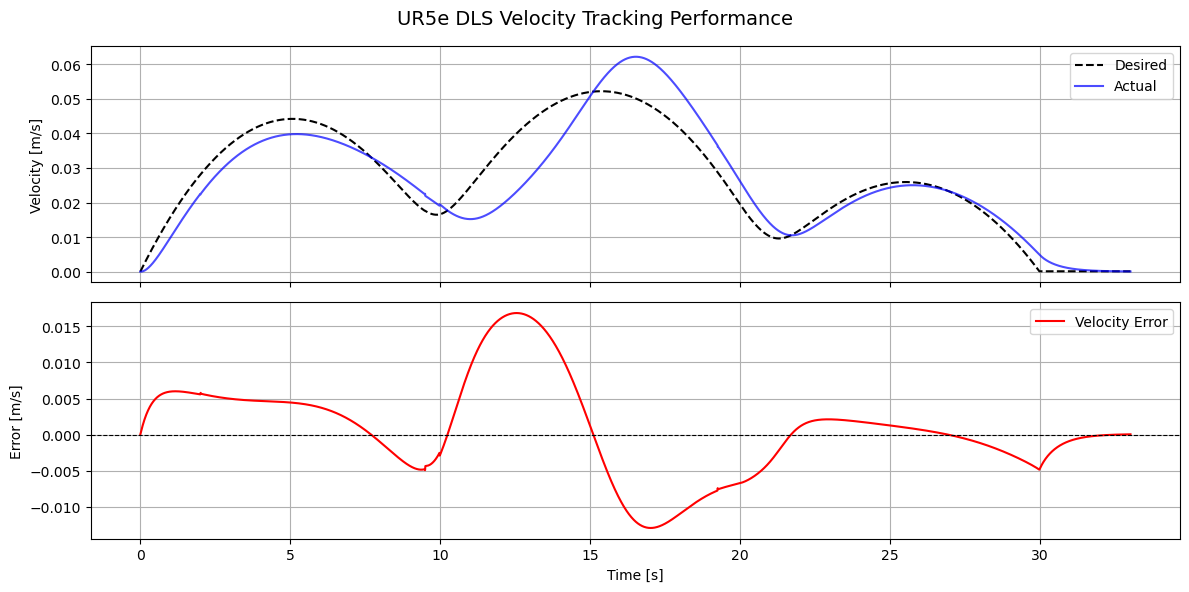

In [18]:
desired_velocity_arr = np.array(ee_desired_velocity)   # shape (N,)
actual_velocity_arr  = np.array(ee_actual_velocity)    # shape (N,)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.suptitle('UR5e DLS Velocity Tracking Performance', fontsize=14)

# 1. 위쪽 그래프: 목표 속도 vs 실제 속도 겹쳐 그리기 ([:, 0] 제거)
ax1.plot(times, desired_velocity_arr, 'k--', label='Desired') # 점선
ax1.plot(times, actual_velocity_arr, 'b-', alpha=0.7, label='Actual') # 실선
ax1.set_ylabel('Velocity [m/s]')
ax1.legend()
ax1.grid(True)

# 2. 아래쪽 그래프: 트래킹 에러 ([:, 0] 제거)
ax2.plot(times, desired_velocity_arr - actual_velocity_arr, 'r-', label='Velocity Error')
ax2.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax2.set_ylabel('Error [m/s]')
ax2.set_xlabel('Time [s]')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

#### 관절 토크/입력이 부드러운지 joint vel 

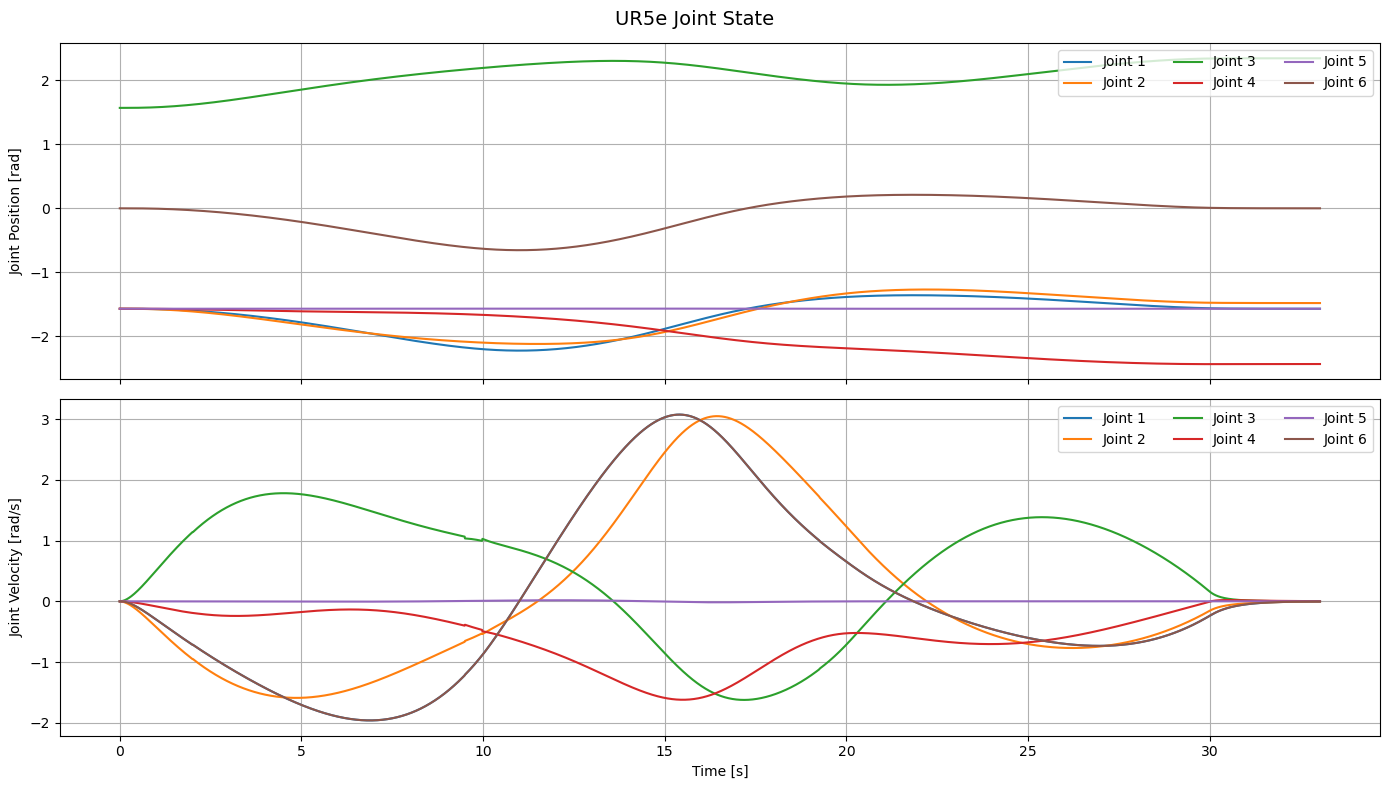

In [19]:
q_arr  = np.array(q_log)   # shape (N, 6)
dq_arr = np.array(dq_log)  # shape (N, 6)
labels = [f'Joint {i+1}' for i in range(6)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('UR5e Joint State', fontsize=14)

for i in range(6):
    ax1.plot(times, q_arr[:, i], label=labels[i])
ax1.set_ylabel('Joint Position [rad]')
ax1.legend(loc='upper right', ncol=3)
ax1.grid(True)

for i in range(6):
    ax2.plot(times, dq_arr[:, i], label=labels[i])
ax2.set_ylabel('Joint Velocity [rad/s]')
ax2.set_xlabel('Time [s]')
ax2.legend(loc='upper right', ncol=3)
ax2.grid(True)

plt.tight_layout()
plt.show()
